# Point-Process JSCC — codes temporels sur un canal à jitter

```
source S  --encodeur-->  X  --jitter-->  Y = X + Z  --decodeur-->  S_hat
```

`Z_i ~ N(0, sigma_J^2)`, `N_X = N_S`, `R = Ts/Tc = 1`, `D = E[(1/N) sum_i (T_i - T_hat_i)^2]`.

Trois systèmes comparés partout, à débit et nombre d'événements identiques :

| système | X | S_hat |
| --- | --- | --- |
| `uncoded` | `S` | `Y` |
| `decoder` | `S` | `dec(Y)` |
| `jscc` | `enc(S)` | `dec(Y)` |


## Paramètres jouables

Tout se règle dans `Config` ci-dessous. Chaque champ porte son rôle et sa plage utile.

Deux conventions à connaître avant de toucher aux valeurs.

Le **gap moyen** `mean_gap = Ts/(N+1)` est l'unité naturelle du problème. Le jitter, la
borne de déplacement et les distorsions sont tous à lire relativement à lui, et c'est
`sigma_J / mean_gap` qui pilote le régime, pas `sigma_J` seul.

Les **têtes de sortie sont initialisées à zéro**, donc à l'initialisation l'encodeur
produit `X = S` et le décodeur produit `S_hat = Y`. Les deux systèmes appris démarrent
exactement sur `uncoded` et ne peuvent que s'en écarter. Le PDF met en garde contre les
problèmes d'optimisation ; c'est la précaution correspondante.

Les contraintes du sujet sont structurelles, jamais pénalisées : `N_X = N_S` parce que
l'encodeur sort un déplacement par événement, `R = 1` parce que `Tc` est une propriété
qui retourne `Ts`, et `X` dans `[0, Tc]` par la borne `max_disp` puis le rabattement.


In [1]:
from dataclasses import dataclass, replace, asdict, fields
import math, time, json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source ------------------------------------------------
    n_events: int = 8          # N, événements par bloc, fixé. Utile: 4..32.
    Ts: float = 1.0            # durée du bloc source. Tc = Ts puisque R = 1.
    source: str = "poisson"    # "poisson" (étape 1) | "gamma" (étape 2) | "hawkes"
    gamma_k: float = 1.0       # forme du renouvellement Gamma. 1, 2, 4, 8.
                               # k=1 exponentiel donc Poisson, k grand régulier.
    hawkes_branching: float = 0.5   # n = alpha/beta dans (0,1): part du taux qui
                                     # vient de l'auto-excitation plutôt que du
                                     # fond. Utile: 0.1..0.85. n->0: quasi-Poisson.
                                     # n->1: critique, rafales instables.
    hawkes_decay: float = 1.0        # durée de vie de l'auto-excitation, unités
                                      # de gap moyen. Utile: 0.2..5. Petit: rafales
                                      # serrées et brèves. Grand: excitation étalée.

    # ---------------- canal -------------------------------------------------
    sigma_J: float = 0.0111    # écart-type du jitter, unités de Ts.
                               # Utile: 0.05*mean_gap .. 1.0*mean_gap.
    sort_output: bool = True   # le décodeur reçoit l'ensemble trié. False garde
                               # l'ordre d'émission et supprime les inversions.

    # ---------------- encodeur ----------------------------------------------
    disp_mode: str = "bounded" # "bounded": delta = max_disp*mean_gap*tanh(.)
                               # "free":    delta non borné
    max_disp: float = 1.0      # borne du déplacement en gaps moyens. 0.1 .. 4.
    window: str = "clamp"      # "clamp" confine X à [0, Tc], ce que le PDF impose
                               # puisque X est un processus sur la durée Tc.
                               # "none" laisse l'encodeur sortir de la fenêtre, ce
                               # qui casse R = Ts/Tc = 1: la fraction d'événements
                               # concernés est mesurée par frac_X_out_preclamp.

    # ---------------- décodeur ----------------------------------------------
    dec_residual: bool = True  # S_hat = Y + correction. False: sortie directe,
                               # qui ne démarre alors pas sur uncoded.

    # ---------------- réseaux -----------------------------------------------
    hidden: int = 128          # largeur. 32 .. 512.
    depth: int = 3             # nombre de couches cachées. 1 .. 6.

    # ---------------- objectif ----------------------------------------------
    distortion: str = "mse"    # "mse" (eq. 8 du PDF) | "mae" | "huber"
    huber_delta: float = 0.02  # coude de Huber, unités de Ts.

    # ---------------- optimisation ------------------------------------------
    steps: int = 4000          # pas d'Adam. 1000 .. 20000.
    batch: int = 512           # blocs par pas. 128 .. 2048.
    lr: float = 3e-3           # pas maximal du OneCycle. 3e-4 .. 1e-2.
    seed: int = 0
    eval_batch: int = 20000    # blocs par répétition d'évaluation.
    eval_reps: int = 2

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def mean_gap(self) -> float:
        return self.Ts / (self.n_events + 1)


CFG = Config()
print(CFG)
print(f"mean_gap = {CFG.mean_gap:.4f}   sigma_J / mean_gap = {CFG.sigma_J / CFG.mean_gap:.3f}")


Config(n_events=8, Ts=1.0, source='poisson', gamma_k=1.0, sigma_J=0.0111, sort_output=True, disp_mode='bounded', max_disp=1.0, window='clamp', dec_residual=True, hidden=128, depth=3, distortion='mse', huber_delta=0.02, steps=4000, batch=512, lr=0.003, seed=0, eval_batch=20000, eval_reps=2)
mean_gap = 0.1111   sigma_J / mean_gap = 0.100


### Constantes d'exécution

Tout ce qui est répété entre plusieurs cellules (grilles, tirages, tailles
d'échantillon, seeds) est rassemblé ici, dans l'ordre où ça sert plus bas dans le
notebook. Modifier une valeur ici change tout ce qui en dépend, sans avoir à
chasser le même nombre dans chaque cellule de figure.

In [ ]:
# ---- grille de l'étape 1 -------------------------------------------------
SIGMA_GRID = [0.05, 0.1, 0.2, 0.4, 0.8]        # sigma_J / mean_gap balayés
MODES = ["uncoded", "decoder", "jscc"]          # systèmes comparés

# ---- tirages des cellules de visualisation -------------------------------
RASTER_N_BLOCKS, RASTER_SEED = 16, 3            # fig_source_raster
CODE_N_BLOCKS, CODE_SEED = 1500, 4242           # fig_code
IDENTITY_N_BLOCKS, IDENTITY_SEED = 4000, 555    # fig_identity_ecdf
REALISATION_SIGMA, REALISATION_BLOCK, REALISATION_SEED = SIGMA_GRID[-2], 0, 7
CONTROL_SIGMA, CONTROL_BLOCK = SIGMA_GRID[-1], 1  # comparaison des 3 systèmes

# ---- étape 1c: forte intensité pendant l'entraînement --------------------
HIGH_N_MULTIPLIER = 8            # n_events = CFG.n_events * ce facteur
HIGH_N_SIGMA_OVER_GAP = 0.2      # même régime relatif que la grille de l'étape 1
HIGH_N_STEPS = 6000
HIGH_N_EVAL_EVERY = 100


## Conventions de tracé

Palette et style identiques à `temporal-jscc/scripts/visualize.py`, pour que les figures
des deux dossiers se lisent ensemble. Une couleur et un marqueur par système, l'encre
noire réservée aux références (identité, `delta = 0`, `sigma_J^2`, bords de fenêtre).


In [2]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    # 26 points de marge, pas 14: à 14 le titre retombe sur le sous-titre
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)


## Sources

`poisson` : processus de Poisson homogène conditionné à `N` événements, c'est-à-dire
`N` uniformes triés sur `[0, Ts]`.

`gamma` : renouvellement `W_i ~ Gamma(k, mu/k)` de moyenne `mu = mean_gap` fixée, puis
`T = cumsum(W)`. `E[T_N] = N/(N+1) * Ts`, donc quelques événements peuvent dépasser `Ts`.


In [3]:
def _hawkes_burn_and_record(mu, alpha, beta, n_burn, n_events, rng):
    """Un bloc de Hawkes à noyau exponentiel, par amincissement de Ogata (1981).

    L'intensité en excès (la part due à l'auto-excitation) décroît en continu à
    taux `beta` et bondit de `alpha` à chaque événement accepté : sa valeur
    courante est donc un majorant valide de l'intensité jusqu'au prochain
    événement, ce qui rend l'amincissement exact, sans discrétisation du temps.

    `n_burn` événements sont simulés et jetés avant d'enregistrer quoi que ce
    soit. Partir de `excess = 0` (aucun événement passé) biaise les blocs vers
    des gaps trop grands, surtout à forte auto-excitation : le régime
    stationnaire n'est atteint qu'après plusieurs événements d'amorçage
    (vérifié : sans rodage, mean_gap dérive jusqu'à 3x la cible à branching =
    0.85). L'origine du bloc est fixée à la fin du rodage, pas au premier
    événement enregistré : le premier gap reste une variable aléatoire comme
    dans les deux autres sources, pas un zéro forcé.
    """
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < n_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            times.append(t - t0)
            excess += alpha
    return np.array(times[:n_events])


def sample_source(cfg: Config, batch: int, rng: np.random.Generator) -> torch.Tensor:
    """-> (batch, N) temps triés croissants."""
    if cfg.source == "poisson":
        u = rng.random((batch, cfg.n_events)) * cfg.Ts
        t = np.sort(u, axis=1)
    elif cfg.source == "gamma":
        mu, k = cfg.mean_gap, float(cfg.gamma_k)
        w = rng.gamma(shape=k, scale=mu / k, size=(batch, cfg.n_events))
        t = np.cumsum(w, axis=1)
    elif cfg.source == "hawkes":
        lam0 = 1.0 / cfg.mean_gap
        n = float(cfg.hawkes_branching)
        beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
        alpha = n * beta
        mu = lam0 * (1.0 - n)
        t = np.stack([_hawkes_burn_and_record(mu, alpha, beta, 100, cfg.n_events, rng)
                      for _ in range(batch)])
    else:
        raise ValueError(cfg.source)
    return torch.tensor(t, dtype=torch.float32, device=DEVICE)


def source_stats(cfg: Config, batch: int = 40000, seed: int = 12345) -> dict:
    t = sample_source(cfg, batch, np.random.default_rng(seed))
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1]))
    return {"mean_gap": float(g.mean()), "std_gap": float(g.std()),
            "cv_gap": float(g.std() / g.mean()), "mean_last_event": float(t[:, -1].mean()),
            "frac_beyond_Ts": float((t > cfg.Ts).float().mean())}


for k in (1.0, 2.0, 4.0, 8.0):
    print(f"gamma k={k:>4.1f}  {source_stats(replace(CFG, source='gamma', gamma_k=k))}")
print(f"poisson       {source_stats(CFG)}")
for b in (0.0, 0.3, 0.6, 0.85):
    print(f"hawkes n={b:4.2f}  "
          f"{source_stats(replace(CFG, source='hawkes', hawkes_branching=b))}")


gamma k= 1.0  {'mean_gap': 0.11094795912504196, 'std_gap': 0.11087504774332047, 'cv_gap': 0.9993428587913513, 'mean_last_event': 0.8875836133956909, 'frac_beyond_Ts': 0.09102187305688858}
gamma k= 2.0  {'mean_gap': 0.11128317564725876, 'std_gap': 0.07856252789497375, 'cv_gap': 0.705969512462616, 'mean_last_event': 0.8902653455734253, 'frac_beyond_Ts': 0.06268437206745148}
gamma k= 4.0  {'mean_gap': 0.11122878640890121, 'std_gap': 0.055531229823827744, 'cv_gap': 0.4992523193359375, 'mean_last_event': 0.8898301720619202, 'frac_beyond_Ts': 0.03997812420129776}
gamma k= 8.0  {'mean_gap': 0.11122714728116989, 'std_gap': 0.03924885392189026, 'cv_gap': 0.3528711795806885, 'mean_last_event': 0.8898171782493591, 'frac_beyond_Ts': 0.022990625351667404}
poisson       {'mean_gap': 0.11113131046295166, 'std_gap': 0.09927401691675186, 'cv_gap': 0.8933037519454956, 'mean_last_event': 0.8890503644943237, 'frac_beyond_Ts': 0.0}


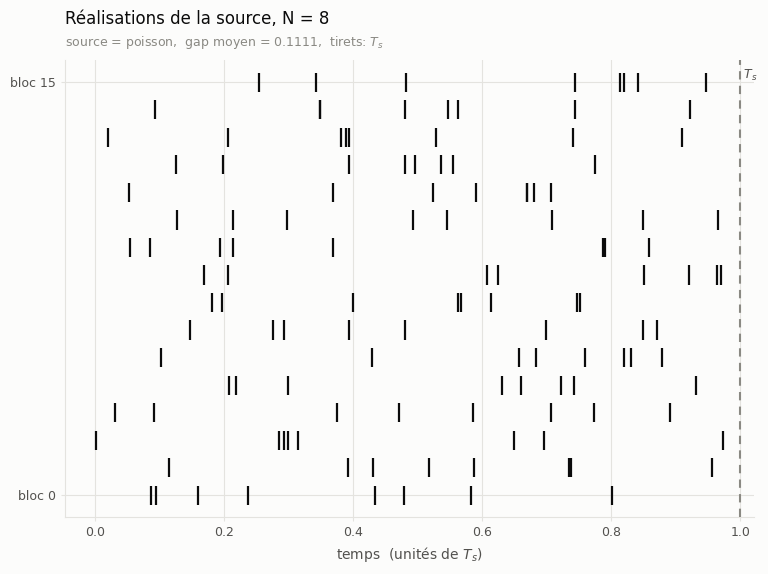

In [4]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    """Réalisations brutes de la source: un bloc par ligne, un trait par événement.

    n_blocks  nombre de réalisations empilées
    seed      tirage
    """
    t = sample_source(cfg, n_blocks, np.random.default_rng(seed)).numpy()
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot([row for row in t], colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.axvline(cfg.Ts, color=MUTED, lw=1.5, ls=(0, (4, 3)), zorder=4)
    ax.text(cfg.Ts, n_blocks - 0.5, " $T_s$", color=INK2, fontsize=9, va="top")
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["bloc 0", f"bloc {n_blocks - 1}"])
    if cfg.source == "poisson":
        label = "source = poisson"
    elif cfg.source == "gamma":
        label = f"source = gamma, k = {cfg.gamma_k:g}"
    else:
        label = (f"source = hawkes, n = {cfg.hawkes_branching:g}, "
                 f"decay = {cfg.hawkes_decay:g} gap")
    style(ax, "temps  (unités de $T_s$)", "",
          f"Réalisations de la source, N = {cfg.n_events}",
          f"{label},  gap moyen = {cfg.mean_gap:.4f},  tirets: $T_s$")
    fig.tight_layout()
    return fig


fig_source_raster(CFG, n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()


`hawkes` : processus auto-excitant à noyau exponentiel,

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

chaque événement augmente temporairement l'intensité, donc les points arrivent en
rafales suivies de silences, contrairement à Poisson où les gaps sont i.i.d. `mu`,
`alpha`, `beta` sont dérivés de `mean_gap`, `hawkes_branching` (n = alpha/beta, la
part du taux qui vient de l'auto-excitation) et `hawkes_decay` (durée de vie de
l'excitation), pour que le taux moyen à l'équilibre reste `1/mean_gap` comme les
deux autres sources. Simulé exactement par amincissement de Ogata (1981), avec un
rodage pour démarrer en régime stationnaire plutôt qu'en phase de chauffe.

In [ ]:
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.0),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.6),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.85, hawkes_decay=0.5),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()


## Canal

`Y = sort(X + Z)`. Le tri est ce qui rend les inversions possibles : deux événements
proches peuvent être échangés par le bruit, et l'appariement `T_i <-> Y_i` est alors faux.
`sort_output=False` désactive le tri.


In [5]:
def channel(x: torch.Tensor, sigma: float, cfg: Config,
            gen: torch.Generator | None = None):
    """(B,N) -> (B,N). Renvoie aussi la permutation appliquée par le tri."""
    z = torch.randn(x.shape, generator=gen, device=x.device) * sigma
    y = x + z
    if cfg.sort_output:
        y, perm = y.sort(dim=1)
    else:
        perm = torch.arange(x.shape[1], device=x.device).expand_as(x)
    return y, perm


def reorder_rates(x: torch.Tensor, perm: torch.Tensor) -> dict:
    """Combien le canal a mélangé les événements."""
    idx = torch.arange(x.shape[1], device=x.device).expand_as(perm)
    moved = perm != idx
    return {"reorder_event_frac": float(moved.float().mean()),
            "reorder_block_frac": float(moved.any(dim=1).float().mean())}


## Systèmes

L'encodeur et le décodeur lisent le même jeu de traits : les temps normalisés et les
gaps. Les gaps sont fournis explicitement parce que la géométrie relative est
précisément la quantité en jeu.

Le déplacement `delta = X - S` est la sortie de l'encodeur, donc `N_X = N_S` par
construction et aucun gain ne peut venir d'un ajout d'événements.


In [6]:
def block_features(t: torch.Tensor, cfg: Config) -> torch.Tensor:
    """(B,N) -> (B,2N) : temps / Ts, puis gaps / mean_gap (premier gap depuis 0)."""
    s = t / cfg.Ts
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1])) / cfg.mean_gap
    return torch.cat([s, g], dim=1)


class MLP(nn.Module):
    """Dernière couche initialisée à zéro: la tête démarre sur la sortie neutre."""

    def __init__(self, d_in, d_out, hidden, depth):
        super().__init__()
        layers, d = [], d_in
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.GELU()]
            d = hidden
        head = nn.Linear(d, d_out)
        nn.init.zeros_(head.weight)
        nn.init.zeros_(head.bias)
        self.net = nn.Sequential(*layers, head)

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = MLP(2 * cfg.n_events, cfg.n_events, cfg.hidden, cfg.depth)

    def forward(self, t):
        cfg = self.cfg
        raw = self.net(block_features(t, cfg))
        if cfg.disp_mode == "bounded":
            delta = cfg.max_disp * cfg.mean_gap * torch.tanh(raw)
        elif cfg.disp_mode == "free":
            delta = cfg.mean_gap * raw
        else:
            raise ValueError(cfg.disp_mode)
        x = t + delta
        if cfg.window == "clamp":
            x = x.clamp(0.0, cfg.Tc)
        return x, delta


class Decoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = MLP(2 * cfg.n_events, cfg.n_events, cfg.hidden, cfg.depth)

    def forward(self, y):
        cfg = self.cfg
        raw = self.net(block_features(y, cfg))
        if cfg.dec_residual:
            return y + cfg.mean_gap * raw
        return cfg.Ts * torch.sigmoid(raw)


class System(nn.Module):
    """mode: "uncoded" (sans paramètre) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, t, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        if self.encoder is None:
            x, delta = t, torch.zeros_like(t)
        else:
            x, delta = self.encoder(t)
        y, perm = channel(x, sigma, self.cfg, gen)
        s_hat = y if self.decoder is None else self.decoder(y)
        return {"s_hat": s_hat, "x": x, "y": y, "delta": delta, "perm": perm}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


## Entraînement et mesures

La perte est la distorsion choisie, sans terme auxiliaire. `measure` renvoie les trois
distorsions quelle que soit celle qui a servi à entraîner, plus des mesures du code
appris : amplitude du déplacement, inversions du canal, gap minimal, débordements.


In [7]:
def distortion_terms(t: torch.Tensor, s_hat: torch.Tensor, cfg: Config) -> dict:
    e = s_hat - t
    return {"mse": (e ** 2).mean(), "mae": e.abs().mean(),
            "huber": F.huber_loss(s_hat, t, delta=cfg.huber_delta)}


def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        t = sample_source(cfg, cfg.batch, rng)
        out = model(t, gen=gen)
        loss = distortion_terms(t, out["s_hat"], cfg)[cfg.distortion]
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 10) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:6d}  loss {float(loss.detach()):.3e}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, sigma=None, seed: int = 99991) -> dict:
    sigma = cfg.sigma_J if sigma is None else sigma
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    acc, reps = {}, cfg.eval_reps
    for _ in range(reps):
        t = sample_source(cfg, cfg.eval_batch, rng)
        o = model(t, sigma=sigma, gen=gen)
        d = {k: float(v) for k, v in distortion_terms(t, o["s_hat"], cfg).items()}
        gx = torch.diff(o["x"].sort(dim=1).values, dim=1)
        gs = torch.diff(t, dim=1)
        x_raw = t + o["delta"]
        row = {**{f"d_{k}": v for k, v in d.items()},
               **reorder_rates(o["x"], o["perm"]),
               "mean_abs_delta_gaps": float(o["delta"].abs().mean() / cfg.mean_gap),
               "min_gap_X_gaps": float(gx.min(dim=1).values.mean() / cfg.mean_gap),
               "min_gap_S_gaps": float(gs.min(dim=1).values.mean() / cfg.mean_gap),
               "frac_X_out_preclamp": float(((x_raw < 0) | (x_raw > cfg.Tc)).float().mean()),
               "frac_X_outside": float(((o["x"] < 0) | (o["x"] > cfg.Tc)).float().mean())}
        for k, v in row.items():
            acc[k] = acc.get(k, 0.0) + v / reps
    model.train()
    return acc | {"sigma_J": sigma, "sigma_over_gap": sigma / cfg.mean_gap,
                  "mode": model.mode, "n_params": model.n_params}


## Étape 1 — source de Poisson

Balayage de `sigma_J` en unités de gap moyen, les trois systèmes au même débit et au même
nombre d'événements. `uncoded` n'a aucun paramètre et n'est pas entraîné.


In [8]:
def run_sweep(base: Config, sigma_grid=SIGMA_GRID, modes=MODES, verbose=True):
    """Un modèle par (sigma, mode). Renvoie la liste des mesures et les modèles."""
    rows, models = [], {}
    for sg in sigma_grid:
        cfg = replace(base, sigma_J=sg * base.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            m["loss_end"] = hist[-1]["loss"] if hist else float("nan")
            rows.append(m)
            models[(sg, mode)] = (model, cfg, hist)
            if verbose:
                print(f"sigma/gap {sg:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  reorder/event {m['reorder_event_frac']:.4f}"
                      f"  |delta| {m['mean_abs_delta_gaps']:.3f} gaps"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


STEP1_ROWS, STEP1_MODELS = run_sweep(CFG)


sigma/gap 0.05  uncoded   d_mse 3.004e-05  reorder/event 0.0428  |delta| 0.000 gaps  (0s)


sigma/gap 0.05  decoder   d_mse 2.965e-05  reorder/event 0.0428  |delta| 0.000 gaps  (4s)


sigma/gap 0.05  jscc      d_mse 2.840e-05  reorder/event 0.0791  |delta| 0.034 gaps  (6s)


sigma/gap 0.10  uncoded   d_mse 1.168e-04  reorder/event 0.0826  |delta| 0.000 gaps  (0s)


sigma/gap 0.10  decoder   d_mse 1.119e-04  reorder/event 0.0826  |delta| 0.000 gaps  (3s)


...

sigma/gap 0.40  decoder   d_mse 1.336e-03  reorder/event 0.2804  |delta| 0.000 gaps  (4s)


sigma/gap 0.40  jscc      d_mse 9.423e-04  reorder/event 0.4535  |delta| 0.412 gaps  (6s)


sigma/gap 0.80  uncoded   d_mse 5.399e-03  reorder/event 0.4558  |delta| 0.000 gaps  (0s)


sigma/gap 0.80  decoder   d_mse 3.742e-03  reorder/event 0.4558  |delta| 0.000 gaps  (3s)


sigma/gap 0.80  jscc      d_mse 2.427e-03  reorder/event 0.5705  |delta| 0.641 gaps  (6s)


In [9]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["sigma_over_gap", "mode", "d_mse", "d_mae",
                    "reorder_event_frac", "mean_abs_delta_gaps",
                    "min_gap_X_gaps", "frac_X_out_preclamp", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells.append(str(v).rjust(w[c]))
        print(" | ".join(cells))


show_table(STEP1_ROWS, title=f"Étape 1 — Poisson, N={CFG.n_events}")
print("\nsigma_J^2 pour référence, en unités de Ts^2 :")
for sg in SIGMA_GRID:
    s = sg * CFG.mean_gap
    print(f"  sigma/gap {sg:4.2f}  sigma_J {s:.5f}  sigma_J^2 {s ** 2:.4e}")


Étape 1 — Poisson, N=8
sigma_over_gap |        mode |       d_mse |       d_mae | reorder_event_frac | mean_abs_delta_gaps | min_gap_X_gaps | frac_X_out_preclamp |    n_params
---------------+-------------+-------------+-------------+--------------------+---------------------+----------------+---------------------+------------
        0.0500 |     uncoded |  3.0040e-05 |      0.0044 |             0.0428 |              0.0000 |         0.1429 |              0.0000 |           0
        0.0500 |     decoder |  2.9651e-05 |      0.0043 |             0.0428 |              0.0000 |         0.1429 |              0.0000 |       36232
        0.0500 |        jscc |  2.8403e-05 |      0.0042 |             0.0791 |              0.0336 |         0.1181 |              0.0139 |       72464
        0.1000 |     uncoded |  1.1684e-04 |      0.0086 |             0.0826 |              0.0000 |         0.1429 |              0.0000 |           0
        0.1000 |     decoder |  1.1190e-04 |      0.0084 | 

### Figures de l'étape 1

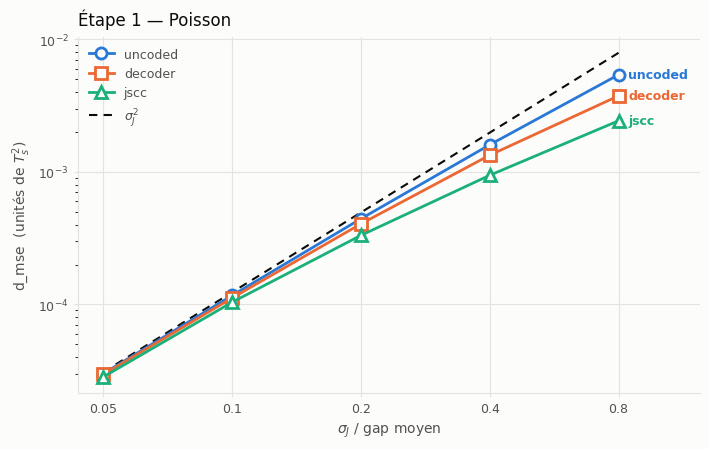

In [10]:
def fig_distortion(rows, metric="d_mse", title="Étape 1 — Poisson"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["sigma_over_gap"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["sigma_over_gap"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    sg = np.array(sorted({r["sigma_over_gap"] for r in rows}))
    mean_gap = rows[0]["sigma_J"] / rows[0]["sigma_over_gap"]
    if metric == "d_mse":
        ax.plot(sg, (sg * mean_gap) ** 2, color=INK, lw=1.5, ls=(0, (4, 3)),
                zorder=4, label="$\\sigma_J^2$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(list(sg))
    ax.set_xticklabels([f"{v:g}" for v in sg], fontsize=9)
    ax.set_xticks([], minor=True)
    ax.set_xlim(right=sg[-1] * 1.55)
    unit = "$T_s^2$" if metric == "d_mse" else "$T_s$"
    style(ax, "$\\sigma_J$ / gap moyen", f"{metric}  (unités de {unit})", title)
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(STEP1_ROWS)
plt.show()


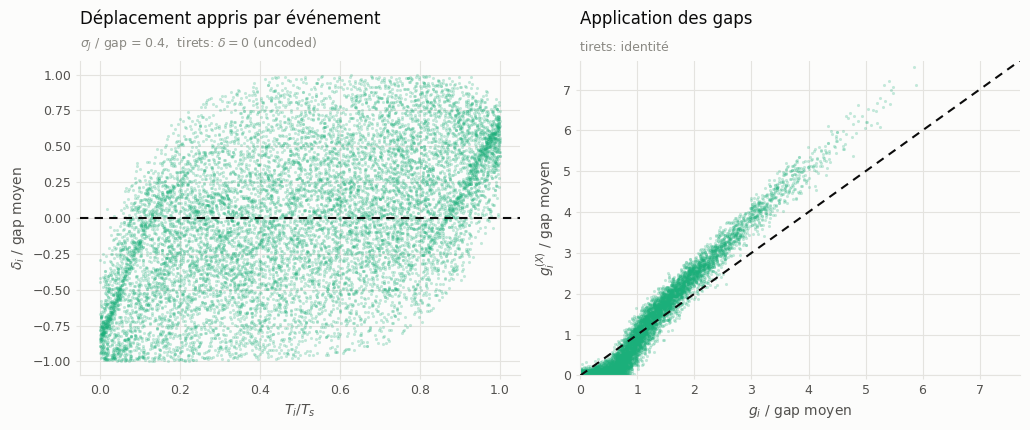

In [11]:
def fig_code(models, sg, n_blocks=1500, seed=4242):
    """Le code appris à un sigma donné: déplacement par événement, et gaps."""
    model, cfg, _ = models[(sg, "jscc")]
    rng = np.random.default_rng(seed)
    with torch.no_grad():
        t = sample_source(cfg, n_blocks, rng)
        x, delta = model.encoder(t)
    t_np = (t.numpy() / cfg.Ts).ravel()
    d_np = (delta.numpy() / cfg.mean_gap).ravel()
    gs = torch.diff(t, dim=1).numpy().ravel() / cfg.mean_gap
    gx = torch.diff(x.sort(dim=1).values, dim=1).numpy().ravel() / cfg.mean_gap

    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), facecolor=SURFACE)
    axes[0].scatter(t_np, d_np, s=5, color=C_JSCC, alpha=0.25, lw=0)
    axes[0].axhline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    style(axes[0], "$T_i / T_s$", "$\\delta_i$ / gap moyen",
          "Déplacement appris par événement",
          f"$\\sigma_J$ / gap = {sg:g},  tirets: $\\delta = 0$ (uncoded)")

    lim = max(gs.max(), gx.max()) * 1.02
    axes[1].scatter(gs, gx, s=5, color=C_JSCC, alpha=0.25, lw=0)
    axes[1].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xlim(0, lim)
    axes[1].set_ylim(0, lim)
    style(axes[1], "$g_i$ / gap moyen", "$g^{(X)}_i$ / gap moyen",
          "Application des gaps", "tirets: identité")
    fig.tight_layout()
    return fig


fig_code(STEP1_MODELS, REALISATION_SIGMA, n_blocks=CODE_N_BLOCKS, seed=CODE_SEED)
plt.show()


### Convergence de l'encodeur vers l'identité, à travers l'aléa de la source

Pour chaque sigma de la grille, on tire `n_blocks` réalisations *indépendantes* de la
source de Poisson (donc l'aléa du process, pas l'aléa de l'entraînement) et on regarde
la fonction de répartition de `|delta_i| / gap_moyen` sur tous les événements de tous
les blocs. Un encodeur qui aurait convergé vers l'identité aurait `delta = 0` partout,
donc une marche à la verticale de 0.


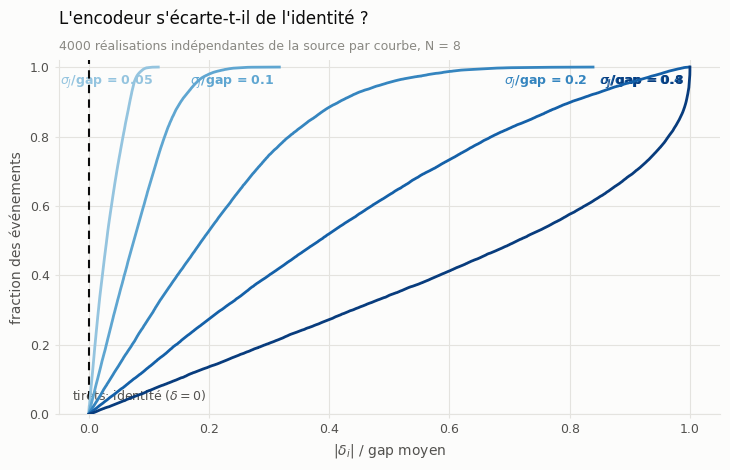

In [12]:
def fig_identity_ecdf(models, sigma_grid=SIGMA_GRID, n_blocks=4000, seed=555):
    fig, ax = plt.subplots(figsize=(7.4, 4.8), facecolor=SURFACE)
    blues = plt.get_cmap("Blues")(np.linspace(0.4, 0.95, len(sigma_grid)))
    for colour, sg in zip(blues, sigma_grid):
        model, cfg, _ = models[(sg, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            t = sample_source(cfg, n_blocks, rng)
            _, delta = model.encoder(t)
        d = np.sort(np.abs(delta.numpy().ravel()) / cfg.mean_gap)
        y = np.arange(1, len(d) + 1) / len(d)
        ax.plot(d, y, color=colour, lw=2.0, zorder=5)
        ax.annotate(f"$\\sigma_J$/gap = {sg:g}", (d[-1], y[-1]),
                    textcoords="offset points", xytext=(-4, -4), color=colour,
                    fontsize=9, fontweight="bold", ha="right", va="top")
    ax.axvline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    ax.text(0.02, 0.04, "tirets: identité ($\\delta = 0$)", transform=ax.transAxes,
            color=INK2, fontsize=9)
    ax.set_ylim(0, 1.02)
    style(ax, "$|\\delta_i|$ / gap moyen", "fraction des événements",
          "L'encodeur s'écarte-t-il de l'identité ?",
          f"{n_blocks} réalisations indépendantes de la source par courbe, "
          f"N = {CFG.n_events}")
    fig.tight_layout()
    return fig


fig_identity_ecdf(STEP1_MODELS, sigma_grid=SIGMA_GRID,
                  n_blocks=IDENTITY_N_BLOCKS, seed=IDENTITY_SEED)
plt.show()


### Étape 1c — le pipeline converge-t-il vers l'identité pendant l'entraînement, à forte intensité ?

Hypothèse à tester (remarque du PDF pour l'étape 1) : la source de Poisson est le cas
le plus "aléatoire" considéré, donc l'encodeur appris pourrait simplement converger
vers la transmission non codée.

`HIGH_N_CFG` reprend `CFG` avec `n_events` multiplié par 8 (intensité forte : 8 fois
plus d'événements sur la même durée `Ts`, donc un gap moyen 8 fois plus petit), au même
`sigma_over_gap` qu'un point de la grille de l'étape 1. `train_track_identity` entraîne
`jscc` en évaluant à intervalle régulier, sur un batch d'évaluation *fixe* (même tirage
à chaque checkpoint), la distorsion et l'écart moyen à l'identité `|delta_i|/gap_moyen`.


In [13]:
def train_track_identity(cfg: Config, eval_every: int = 100, eval_batch: int = 4000,
                          eval_seed: int = 777, verbose: bool = False):
    """Entraîne jscc, logue distorsion et écart-à-l'identité sur un batch fixe."""
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, "jscc").to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)

    t_eval = sample_source(cfg, eval_batch, np.random.default_rng(eval_seed))

    traj = []
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        t = sample_source(cfg, cfg.batch, rng)
        out = model(t, gen=gen)
        loss = distortion_terms(t, out["s_hat"], cfg)[cfg.distortion]
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step == 1 or step % eval_every == 0 or step == cfg.steps:
            model.eval()
            with torch.no_grad():
                eval_gen = torch.Generator(device=DEVICE).manual_seed(eval_seed)
                o = model(t_eval, gen=eval_gen)
                d_mse = float(((o["s_hat"] - t_eval) ** 2).mean())
                delta_mag = float(o["delta"].abs().mean() / cfg.mean_gap)
            model.train()
            traj.append({"step": step, "d_mse": d_mse, "mean_abs_delta_gaps": delta_mag})
            if verbose:
                print(f"  step {step:6d}  d_mse {d_mse:.3e}  |delta| {delta_mag:.4f} gaps"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, traj


HIGH_N_CFG = replace(CFG, n_events=CFG.n_events * HIGH_N_MULTIPLIER, steps=HIGH_N_STEPS)
HIGH_N_CFG = replace(HIGH_N_CFG, sigma_J=HIGH_N_SIGMA_OVER_GAP * HIGH_N_CFG.mean_gap)
print(HIGH_N_CFG)
print(f"mean_gap = {HIGH_N_CFG.mean_gap:.5f}   "
      f"sigma_over_gap = {HIGH_N_CFG.sigma_J / HIGH_N_CFG.mean_gap:.3f}")

UNCODED_REF = measure(System(HIGH_N_CFG, "uncoded"), HIGH_N_CFG)["d_mse"]
print(f"référence uncoded (pas d'apprentissage) : d_mse = {UNCODED_REF:.3e}")

TRACK_MODEL, TRACK_TRAJ = train_track_identity(HIGH_N_CFG, eval_every=HIGH_N_EVAL_EVERY,
                                               verbose=True)


Config(n_events=64, Ts=1.0, source='poisson', gamma_k=1.0, sigma_J=0.0030769230769230774, sort_output=True, disp_mode='bounded', max_disp=1.0, window='clamp', dec_residual=True, hidden=128, depth=3, distortion='mse', huber_delta=0.02, steps=6000, batch=512, lr=0.003, seed=0, eval_batch=20000, eval_reps=2)
mean_gap = 0.01538   sigma_over_gap = 0.200
référence uncoded (pas d'apprentissage) : d_mse = 8.234e-06
  step      1  d_mse 8.233e-06  |delta| 0.0002 gaps  0s


  step    100  d_mse 8.228e-06  |delta| 0.0013 gaps  0s


  step    200  d_mse 8.219e-06  |delta| 0.0027 gaps  1s


  step    300  d_mse 8.192e-06  |delta| 0.0046 gaps  1s


  step    400  d_mse 8.100e-06  |delta| 0.0125 gaps  1s


...

  step   5600  d_mse 7.185e-06  |delta| 0.1149 gaps  15s


  step   5700  d_mse 7.183e-06  |delta| 0.1152 gaps  15s


  step   5800  d_mse 7.182e-06  |delta| 0.1153 gaps  15s


  step   5900  d_mse 7.181e-06  |delta| 0.1154 gaps  15s


  step   6000  d_mse 7.181e-06  |delta| 0.1153 gaps  16s


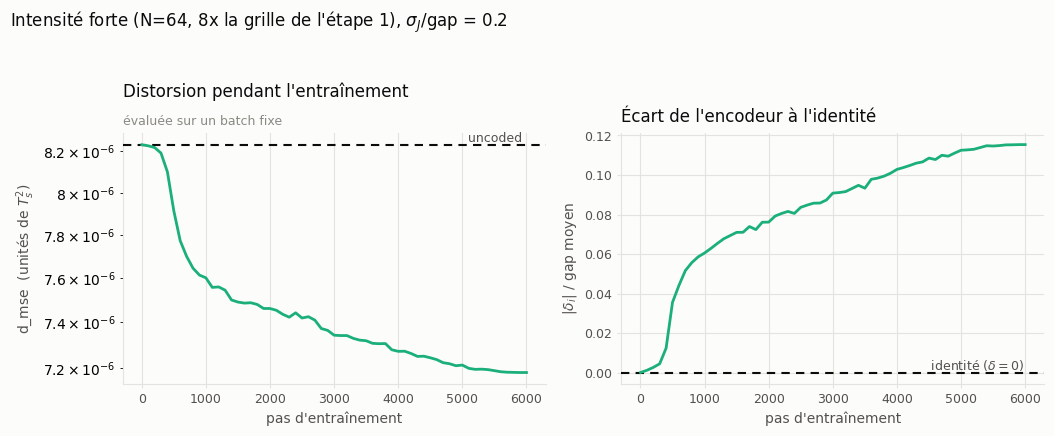

In [14]:
def fig_identity_over_training(traj, uncoded_ref, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), facecolor=SURFACE)
    steps = [r["step"] for r in traj]

    d = [r["d_mse"] for r in traj]
    axes[0].plot(steps, d, color=C_JSCC, lw=2.0, zorder=5, label="jscc")
    axes[0].axhline(uncoded_ref, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].text(steps[-1], uncoded_ref, " uncoded ", color=INK2, fontsize=9,
                 va="bottom", ha="right")
    axes[0].set_yscale("log")
    style(axes[0], "pas d'entraînement", "d_mse  (unités de $T_s^2$)",
          "Distorsion pendant l'entraînement", "évaluée sur un batch fixe")

    dl = [r["mean_abs_delta_gaps"] for r in traj]
    axes[1].plot(steps, dl, color=C_JSCC, lw=2.0, zorder=5)
    axes[1].axhline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].text(steps[-1], 0, " identité ($\\delta=0$) ", color=INK2,
                 fontsize=9, va="bottom", ha="right")
    style(axes[1], "pas d'entraînement", "$|\\delta_i|$ / gap moyen",
          "Écart de l'encodeur à l'identité")

    fig.suptitle(title, color=INK, fontsize=12, x=0.01, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig


fig_identity_over_training(
    TRACK_TRAJ, UNCODED_REF,
    title=(f"Intensité forte (N={HIGH_N_CFG.n_events}, 8x la grille de l'étape 1), "
           f"$\\sigma_J$/gap = {HIGH_N_CFG.sigma_J / HIGH_N_CFG.mean_gap:g}"))
plt.show()


## Étape 1b — une réalisation suivie le long de la chaîne

Quatre lignes, une par étage : la source, le mot de code, la sortie du canal, la
reconstruction. Les segments relient chaque événement à son image, donc un croisement
entre la ligne `X` et la ligne `Y` est une inversion produite par le tri du canal.

Paramètres de la figure : `sg` le sigma pris dans la grille, `mode` le système, `block`
l'indice du bloc tiré, `seed` le tirage.


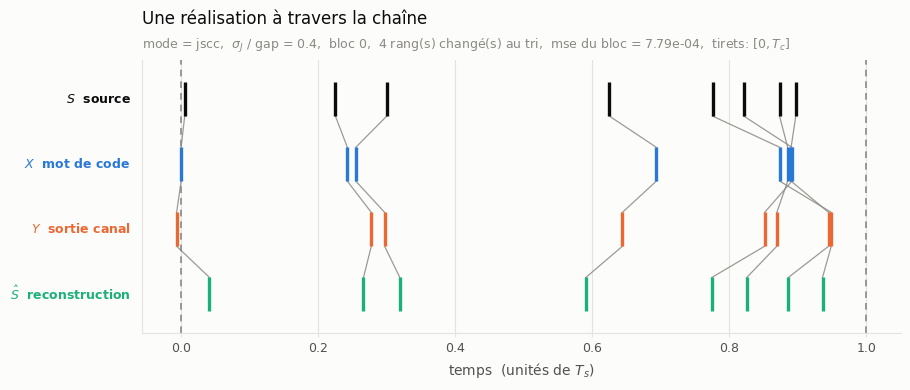

In [15]:
def fig_realisation(models, sg, mode="jscc", block=0, seed=7):
    model, cfg, _ = models[(sg, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        t = sample_source(cfg, block + 1, rng)
        o = model(t, gen=gen)
    S = t[block].numpy()
    X = o["x"][block].numpy()
    Y = o["y"][block].numpy()
    H = o["s_hat"][block].numpy()
    perm = o["perm"][block].numpy()

    rows = [("$S$  source", S, INK),
            ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER),
            ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")

    # correspondances: S_i -> X_i, puis X_{perm[j]} -> Y_j, puis Y_j -> S_hat_j
    for i in range(len(S)):
        ax.plot([S[i], X[i]], [3 - 0.26, 2 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)
    for j in range(len(Y)):
        ax.plot([X[perm[j]], Y[j]], [2 - 0.26, 1 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)
        ax.plot([Y[j], H[j]], [1 - 0.26, 0 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)

    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    n_swap = int((perm != np.arange(len(X))).sum())
    err = float(((H - S) ** 2).mean())
    sub = (f"mode = {mode},  $\\sigma_J$ / gap = {sg:g},  bloc {block},  "
           f"{n_swap} rang(s) changé(s) au tri,  mse du bloc = {err:.2e},  "
           "tirets: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6)
    ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "",
          "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


fig_realisation(STEP1_MODELS, REALISATION_SIGMA, mode="jscc",
                block=REALISATION_BLOCK, seed=REALISATION_SEED)
plt.show()


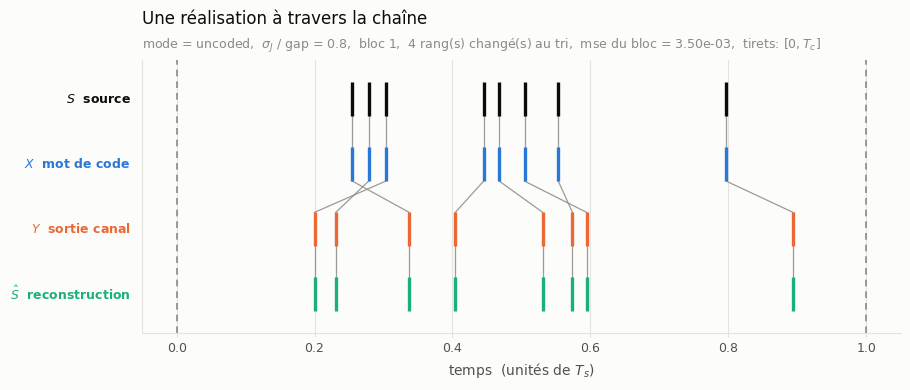

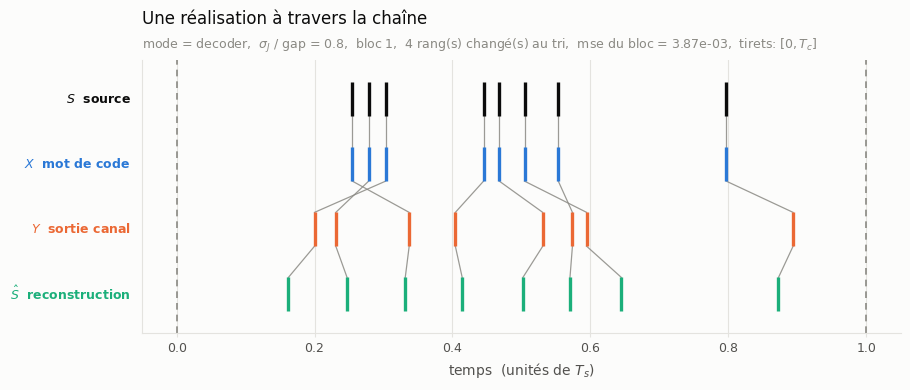

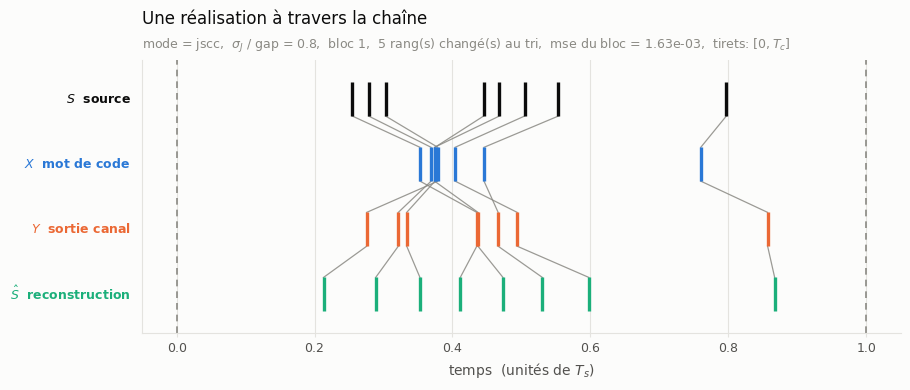

In [16]:
# les trois systèmes sur le même bloc, au jitter le plus fort de la grille
for m in MODES:
    fig_realisation(STEP1_MODELS, CONTROL_SIGMA, mode=m, block=CONTROL_BLOCK)
    plt.show()
